# Planetary-dominated eddies: background tilt direction

## Hypothesis

Where the planetary PV-gradient contribution dominates, the observed tilt should reveal the direction in which each polarity naturally tends to tilt. The working vector hypothesis is:

1. AEs and CEs share a zonal tilt component with approximately the same sign and magnitude.
2. Their meridional components have comparable magnitudes but opposite signs: AEs equatorward and CEs poleward.
3. The zonal sign is estimated from the data rather than assumed, because preliminary notes disagree on whether it is eastward or westward.

Direction is analysed only when `TiltDis >= 5 km`. Results are summarised by eddy as well as by daily observation to avoid treating every day of a long track as an independent replicate.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

## 1. Load data and define the planetary-dominated population

In [2]:
DOMINANCE_FACTOR = 2.0
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 5.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
df = tilt.add_pv_gradient_terms(df, grid, core_mean=True)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR,
    min_open_ocean_depth_m=MIN_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df, config)
planetary = d[d.open_ocean_planetary & d.direction_valid].copy()

# Compass bearing: 0° = north and 90° = east.
planetary['tilt_x_km'] = planetary.TiltDis * np.sin(np.deg2rad(planetary.TiltDir))
planetary['tilt_y_km'] = planetary.TiltDis * np.cos(np.deg2rad(planetary.TiltDir))

display(planetary.groupby('Cyc').agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_depth_m=('h', 'median'), median_tilt_km=('TiltDis', 'median')
).round(2))

,observations,eddies,median_depth_m,median_tilt_km
Cyc,,,,
AE,5184,364,4837.76,16.64
CE,1069,146,4853.47,15.36


## 2. Spatial and directional context

The maps check that the selected population is genuinely offshore. The polar distributions show bearings, while the component plots directly test the vector hypothesis.

AE mean tilt dir 18,    tilt dis 21 km
CE mean tilt dir 154,    tilt dis 20 km
Planetary ≥ 2× and depth ≥ 3,000 m


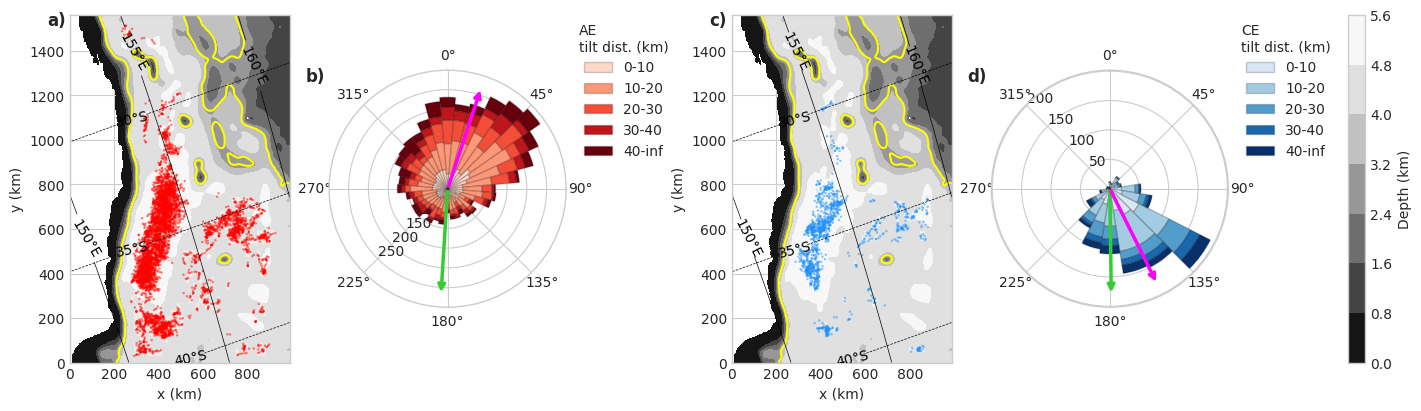

In [10]:
fig = plt.figure(figsize=(14, 4), constrained_layout=True)

axs = [
    fig.add_subplot(1, 4, 1),
    fig.add_subplot(1, 4, 2, projection='polar'),
    fig.add_subplot(1, 4, 3),
    fig.add_subplot(1, 4, 4, projection='polar')
]

mag_bins = [0, 10, 20, 30, 40, np.inf]

for i, cyc in enumerate(['AE', 'CE']):
    ax, axw = axs[2*i], axs[2*i+1]
    df = planetary[planetary.Cyc == cyc].copy()
    cmap = 'Reds' if cyc == 'AE' else 'Blues'
    col = 'r' if cyc == 'AE' else 'dodgerblue'
    colors = getattr(plt.cm, cmap)(np.linspace(.15, 1, len(mag_bins)-1))

    # Map
    bath = ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h/1e3, np.nan),
        cmap='Greys_r'
    )

    ax.hist2d(df.xc, df.yc, bins=50, cmap=cmap, alpha=.6, cmin=2)
    ax.scatter(df.xc, df.yc, s=3, c=col, alpha=.5, edgecolors='none')
    ax.contour(grid.X_grid, grid.Y_grid, grid.h,
               levels=[MIN_DEPTH_m], colors='yellow')

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.set_xlim(grid.X_grid.min(), grid.X_grid.max())
    ax.set_ylim(grid.Y_grid.min(), grid.Y_grid.max())

    ax.set_aspect('equal', adjustable='box')

    # Windrose
    df = df.dropna(subset=['TiltDir', 'TiltDis'])
    tilt.plot_windrose(axw, df, title='', mag_bins=mag_bins, colors=colors)#, rotate=20)

    # PV arrow
    theta = np.deg2rad(
        planetary.loc[planetary.Cyc == cyc, 'PV_grad_theta'].dropna()
    )
    theta_mean = np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta)))
    rmax = axw.get_ylim()[1]
    axw.annotate(
        '',
        xy=(theta_mean, 0.9*rmax),
        xytext=(theta_mean, 0),
        arrowprops=dict(arrowstyle='->', lw=2.5, color='limegreen')
    )

    # tilt arrow
    theta = np.deg2rad(
        planetary.loc[planetary.Cyc == cyc, 'TiltDir'].dropna()
    )
    theta_mean = np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta)))
    print(f'{cyc} mean tilt dir {np.rad2deg(theta_mean):.0f},\
    tilt dis {planetary[planetary.Cyc==cyc].TiltDis.mean():.0f} km')
    axw.annotate(
        '',
        xy=(theta_mean, 0.9*rmax),
        xytext=(theta_mean, 0),
        arrowprops=dict(arrowstyle='->', lw=2.5, color='magenta')
    )
    
    axw.legend(
        title=f'{cyc}\ntilt dist. (km)',
        loc='upper left',
        bbox_to_anchor=(1.0, 1.25),
        frameon=False
    )

# Single bathymetry colourbar
cbar = fig.colorbar(bath, ax=axs, orientation='vertical',
                    fraction=.02, pad=.01)
cbar.set_label('Depth (km)')

for ax, label in zip(axs, ['a)', 'b)', 'c)', 'd)']):
    ax.text(-0.1, 1.01, label,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=12, fontweight='bold')

print('Planetary ≥ 2×' if MIN_DEPTH_m==0.0 else f'Planetary ≥ 2× and depth ≥ {MIN_DEPTH_m:,.0f} m')
plt.show()

## 3. Eddy-level vector components

First average each component within each eddy. These eddy means, rather than individual days, form the principal sampling units. Positive x is eastward and positive y is northward.

,eddies,mean_x_km,median_x_km,mean_y_km,median_y_km
Cyc,,,,,
AE,364,0.15,1.05,5.62,6.02
CE,146,5.30,5.05,-11.29,-8.52


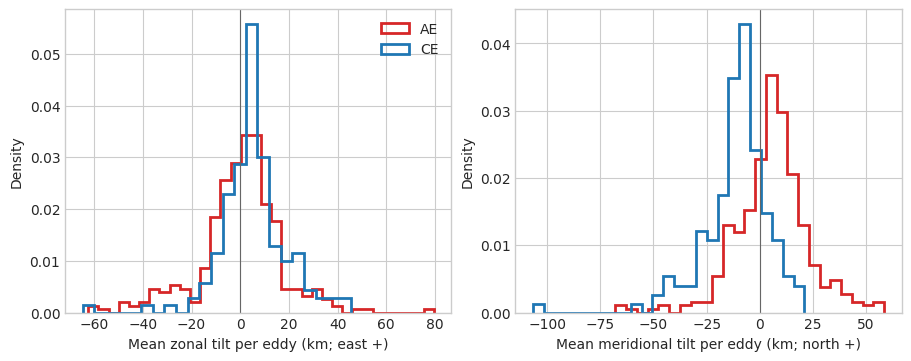

In [5]:
eddy_vectors = (planetary.groupby(['Cyc', 'Eddy'], as_index=False)
                .agg(x_km=('tilt_x_km', 'mean'), y_km=('tilt_y_km', 'mean'),
                     tilt_km=('TiltDis', 'mean'), observations=('Day', 'size')))
display(eddy_vectors.groupby('Cyc').agg(
    eddies=('Eddy', 'size'), mean_x_km=('x_km', 'mean'), median_x_km=('x_km', 'median'),
    mean_y_km=('y_km', 'mean'), median_y_km=('y_km', 'median')
).round(2))

fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    part = eddy_vectors[eddy_vectors.Cyc == cyc]
    axs[0].hist(part.x_km, bins='fd', density=True, histtype='step', lw=2, color=color, label=cyc)
    axs[1].hist(part.y_km, bins='fd', density=True, histtype='step', lw=2, color=color, label=cyc)
for ax, label in zip(axs, ['Mean zonal tilt per eddy (km; east +)', 'Mean meridional tilt per eddy (km; north +)']):
    ax.axvline(0, color='0.4', lw=.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
axs[0].legend(frameon=False);

## 4. Eddy-bootstrap uncertainty and explicit hypothesis contrasts

The shared-zonal hypothesis predicts `AE_x - CE_x ≈ 0`. The opposite-meridional hypothesis predicts `AE_y + CE_y ≈ 0`, alongside AE and CE meridional means having opposite signs. Bootstrap intervals are resampled over eddies.

In [6]:
rng = np.random.default_rng(42)
N_BOOT = 10_000
ae = eddy_vectors[eddy_vectors.Cyc == 'AE']
ce = eddy_vectors[eddy_vectors.Cyc == 'CE']
boot = np.empty((N_BOOT, 4))
for i in range(N_BOOT):
    a = ae.sample(len(ae), replace=True, random_state=rng.integers(2**32 - 1))
    c = ce.sample(len(ce), replace=True, random_state=rng.integers(2**32 - 1))
    boot[i] = [a.x_km.mean(), c.x_km.mean(), a.y_km.mean(), c.y_km.mean()]

contrasts = pd.DataFrame({
    'quantity': ['AE mean x', 'CE mean x', 'AE x − CE x', 'AE mean y', 'CE mean y', 'AE y + CE y'],
    'estimate_km': [ae.x_km.mean(), ce.x_km.mean(), ae.x_km.mean()-ce.x_km.mean(),
                    ae.y_km.mean(), ce.y_km.mean(), ae.y_km.mean()+ce.y_km.mean()],
    'low_95_km': np.percentile(np.c_[boot[:,0], boot[:,1], boot[:,0]-boot[:,1],
                                      boot[:,2], boot[:,3], boot[:,2]+boot[:,3]], 2.5, axis=0),
    'high_95_km': np.percentile(np.c_[boot[:,0], boot[:,1], boot[:,0]-boot[:,1],
                                       boot[:,2], boot[:,3], boot[:,2]+boot[:,3]], 97.5, axis=0),
})
display(contrasts.round(2))

,quantity,estimate_km,low_95_km,high_95_km
0,AE mean x,0.15,-1.62,1.92
1,CE mean x,5.30,3.03,7.48
2,AE x − CE x,-5.15,-7.98,-2.24
3,AE mean y,5.62,3.84,7.43
4,CE mean y,-11.29,-13.97,-8.72
5,AE y + CE y,-5.67,-8.87,-2.53


## 5. Sensitivity checks

Repeat the component estimates for dominance factors 2, 3 and 4 and minimum depths of 2,000, 3,000 and 4,000 m. A robust background direction should not depend on one arbitrary cutoff.

In [7]:
rows = []
for factor in [2.0, 3.0, 4.0]:
    for depth in [2000.0, 3000.0, 4000.0]:
        cfg = PVAlignmentConfig(dominance_factor=factor, min_open_ocean_depth_m=depth, min_tilt_distance_km=MIN_TILT_km)
        use = add_pv_alignment_diagnostics(df, cfg)
        use = use[use.open_ocean_planetary & use.direction_valid].copy()
        use['x'] = use.TiltDis * np.sin(np.deg2rad(use.TiltDir))
        use['y'] = use.TiltDis * np.cos(np.deg2rad(use.TiltDir))
        means = use.groupby(['Cyc', 'Eddy'])[['x', 'y']].mean().groupby('Cyc').mean()
        for cyc in means.index:
            rows.append({'dominance_factor': factor, 'min_depth_m': depth, 'Cyc': cyc,
                         'mean_x_km': means.loc[cyc, 'x'], 'mean_y_km': means.loc[cyc, 'y'],
                         'eddies': use.loc[use.Cyc == cyc, 'Eddy'].nunique()})
display(pd.DataFrame(rows).round(2))

,dominance_factor,min_depth_m,Cyc,mean_x_km,mean_y_km,eddies
0,2.0,2000.0,AE,0.15,5.62,364
1,2.0,2000.0,CE,5.30,-11.29,146
2,2.0,3000.0,AE,0.15,5.62,364
3,2.0,3000.0,CE,5.30,-11.29,146
4,2.0,4000.0,AE,0.15,5.62,364
5,2.0,4000.0,CE,5.30,-11.29,146
6,3.0,2000.0,AE,0.44,5.16,228
7,3.0,2000.0,CE,6.02,-10.09,65
8,3.0,3000.0,AE,0.44,5.16,228
9,3.0,3000.0,CE,6.02,-10.09,65
